# 可选实验：诊断偏差与方差

在上一个可选实验中，你学习了如何通过测量训练误差和交叉验证误差来评估学习算法的性能。根据这些值，你可以量化模型的表现，这有助于你决定在特定应用中使用哪个模型。在本实验中，你将在此基础上进一步探索一些提升模型性能的技巧。事实证明，训练误差和交叉验证误差可以告诉你下一步该尝试什么来改进模型。具体来说，它可以显示你是存在高偏差（欠拟合）还是高方差（过拟合）问题。下面的讲座幻灯片给出了一个示例：

<img src='images/C2_W3_BiasVariance.png' width=75%>

最左边的图显示了高偏差问题，模型没有捕捉到训练数据中的模式。因此，你会得到较高的训练误差和交叉验证误差。另一方面，最右边的图显示了高方差问题，模型对训练集过拟合。因此，即使训练误差很低，它在新样本上的表现也会很差。这表现为较高的交叉验证误差。理想的模型应该是中间的图，它成功地从训练集中学习，并且能够很好地泛化到未见过的数据。讲座中给出了一些关于如何实现这个"恰到好处"模型的建议。

要修复高偏差问题，你可以：
* 尝试添加多项式特征
* 尝试获取额外的特征
* 尝试减小正则化参数

要修复高方差问题，你可以：
* 尝试增大正则化参数
* 尝试使用更小的特征集
* 获取更多的训练样本

你将在本实验中尝试所有这些技巧。让我们开始吧！

## 建立基准性能水平

在诊断模型的高偏差或高方差问题之前，首先了解你可以合理达到的误差水平通常会很有帮助。正如课程中提到的，你可以使用以下任何一种方法来设定基准性能水平。

* 人类水平的表现
* 竞争算法的表现
* 基于经验的猜测

现实世界的数据可能非常嘈杂，要达到0%的误差通常是不可行的。例如，你可能认为存在高偏差问题，因为在一个计算机视觉应用中你得到了10%的训练误差和15%的交叉验证误差。然而，你后来发现即使是人类也无法达到比10%更好的误差。如果你将此视为基准水平，那么你现在反而有了一个高方差问题，因为你已经优先考虑最小化交叉验证误差和训练误差之间的差距。

有了这些背景知识，让我们开始探索解决这些问题的技术。

## 导入和实验设置

除了来自scikit-learn的几个[线性回归器](https://scikit-learn.org/stable/modules/classes.html#classical-linear-regressors)之外，本实验中使用的所有其他函数都在本notebook外部的`utils.py`文件中。你将主要使用与上一个实验相同的代码，因此不需要在这里再次查看每一行。它主要包含用于拆分数据的函数，以及用于遍历参数列表（例如多项式的阶数、正则化参数）并绘制每个参数的训练误差和交叉验证误差的函数。你可以自由探索上述文件中的代码以查看其实现。

In [1]:
# 用于构建线性回归模型
from sklearn.linear_model import LinearRegression, Ridge

# 导入utils.py中的实验工具函数
import utils 

I0000 00:00:1785856113.830365  143467 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785856113.875869  143467 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785856114.960489  143467 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 修复高偏差

你将首先了解当模型欠拟合时可以尝试的方法。换句话说，当训练误差远差于基准性能水平时。

### 尝试添加多项式特征

你已经在上一个实验中见过这个方法。添加多项式特征可以帮助你的模型学习数据中更复杂的模式。这里再次展示一个图表示例，显示随着你添加更多多项式特征，训练误差和交叉验证误差如何变化。你将使用一个具有一个特征和一个目标的回归问题的合成数据集。此外，你还将定义一个任意的基准性能并将其包含在图表中。

the shape of the training set (input) is: (60, 1)
the shape of the training set (target) is: (60,)

the shape of the cross validation set (input) is: (20, 1)
the shape of the cross validation set (target) is: (20,)

first 5 rows of the training inputs (1 feature):
 [[3757.57575758]
 [2878.78787879]
 [3545.45454545]
 [1575.75757576]
 [1666.66666667]]



/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) m

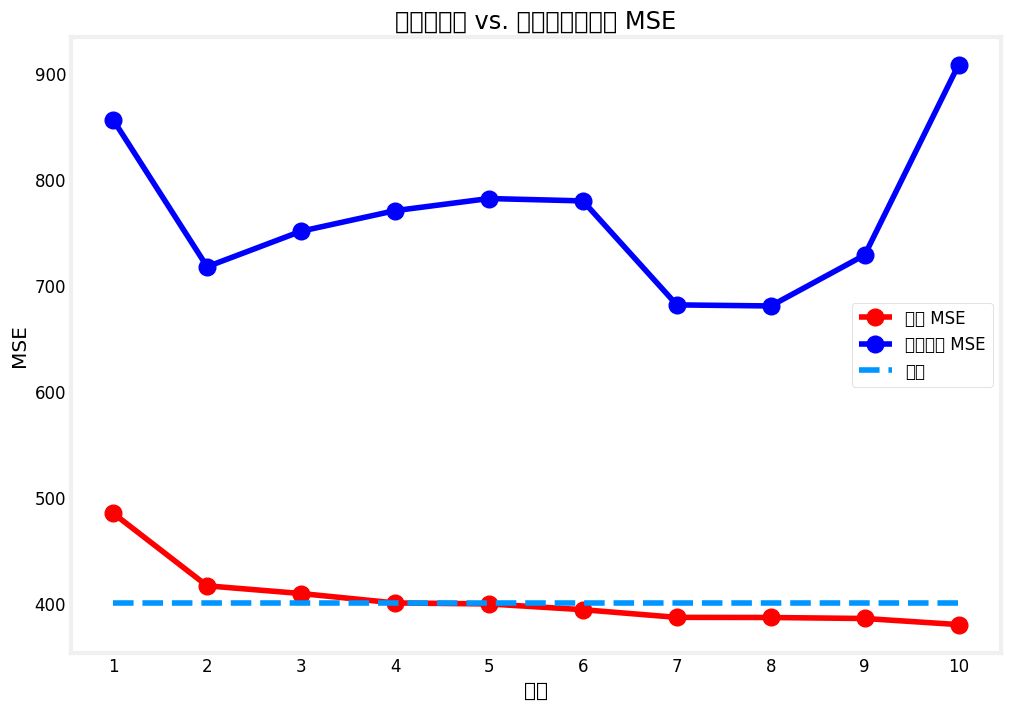

In [2]:
# 将数据集拆分为训练集、交叉验证集和测试集
x_train, y_train, x_cv, y_cv, x_test, y_test = utils.prepare_dataset('data/c2w3_lab2_data1.csv')

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")

# 预览前5行
print(f"first 5 rows of the training inputs (1 feature):\n {x_train[:5]}\n")

# 实例化回归模型类
model = LinearRegression()

# 训练并绘制多项式回归模型
utils.train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree=10, baseline=400)

如你所见，添加的多项式特征越多，模型对训练数据的拟合就越好。在这个例子中，它甚至表现得比基准更好。此时，你可以说阶数大于4的模型是低偏差的，因为它们的表现接近或优于基准。

然而，如果基准定义得更低（例如，你咨询了专家关于可接受的误差），那么这些模型仍然被认为是高偏差的。然后你可以尝试其他方法来改进这一点。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) m

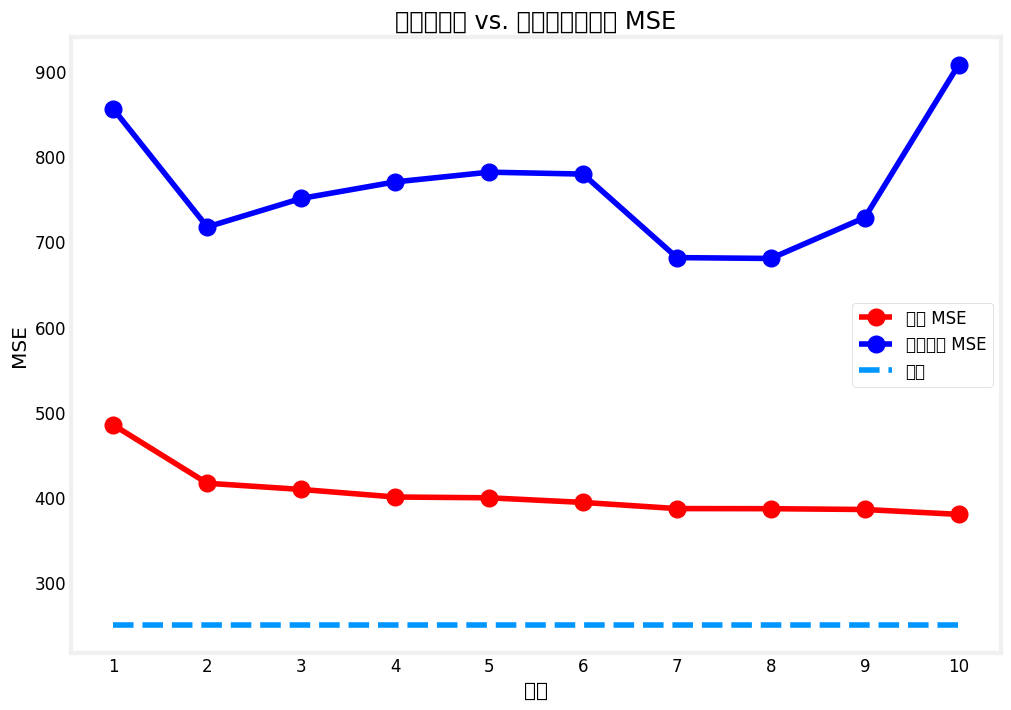

In [3]:
# 训练并绘制多项式回归模型。偏差定义较低。
utils.train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree=10, baseline=250)

### 尝试获取额外的特征

你可以尝试的另一件事是获取其他特征。假设在你得到上述结果后，你决定启动另一个数据收集活动来捕获另一个特征。你的数据集现在将有2列输入特征，如下所示。

In [4]:
x_train, y_train, x_cv, y_cv, x_test, y_test = utils.prepare_dataset('data/c2w3_lab2_data2.csv')

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")

# 预览前5行
print(f"first 5 rows of the training inputs (2 features):\n {x_train[:5]}\n")

the shape of the training set (input) is: (60, 2)
the shape of the training set (target) is: (60,)

the shape of the cross validation set (input) is: (20, 2)
the shape of the cross validation set (target) is: (20,)

first 5 rows of the training inputs (2 features):
 [[3.75757576e+03 5.49494949e+00]
 [2.87878788e+03 6.70707071e+00]
 [3.54545455e+03 3.71717172e+00]
 [1.57575758e+03 5.97979798e+00]
 [1.66666667e+03 1.61616162e+00]]



现在看看这对与之前相同的训练过程有什么影响。你会注意到训练误差现在更接近（甚至优于）基准。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) m

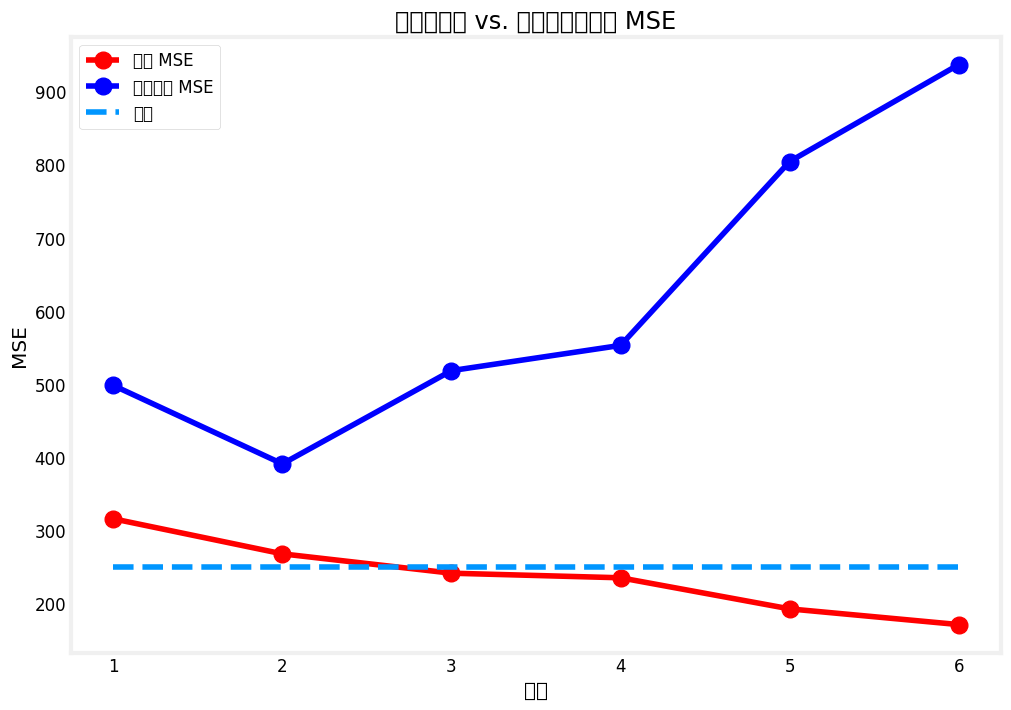

In [5]:
# 实例化模型类
model = LinearRegression()

# 训练并绘制多项式回归模型。使用的数据集有两个特征。
utils.train_plot_poly(model, x_train, y_train, x_cv, y_cv, max_degree=6, baseline=250)

### 尝试减小正则化参数

此时，你可能希望引入正则化以避免过拟合。需要注意的一点是，如果你将正则化参数设置得过高，可能会使模型欠拟合。下面的单元格使用[Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge)类训练一个4阶多项式模型，该类允许你设置正则化参数（即lambda或$\lambda$）。你将尝试几个值并比较结果。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) m

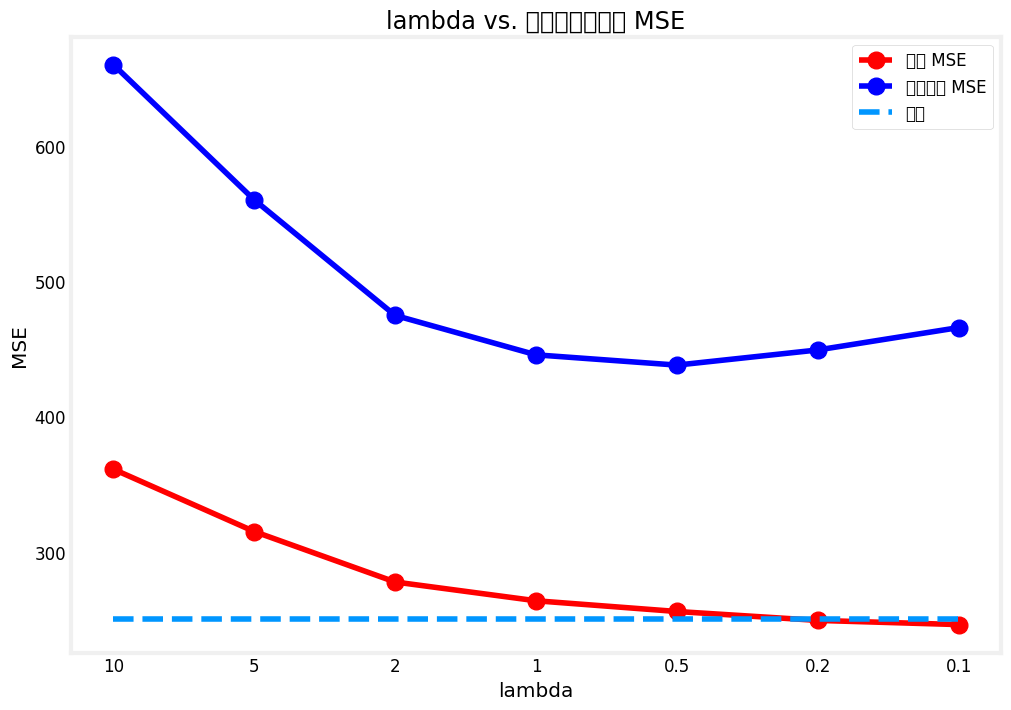

In [6]:
# 定义要绘制的lambda值
reg_params = [10, 5, 2, 1, 0.5, 0.2, 0.1]

# 定义多项式阶数并为每个lambda值进行训练
utils.train_plot_reg_params(reg_params, x_train, y_train, x_cv, y_cv, degree= 4, baseline=250)

结果图显示初始$\lambda$为`10`，如你所见，此时训练误差比基准更差。这意味着它对`w`参数施加了巨大的惩罚，这阻止了模型学习数据中更复杂的模式。随着你减小$\lambda$，模型放宽了这个限制，训练误差能够接近基准性能。

## 修复高方差

你现在将了解当模型对训练集过拟合时可以尝试的一些方法。主要目标是拥有一个能够很好地泛化到新样本的模型，因此你需要最小化交叉验证误差。

### 尝试增大正则化参数

与上面最后一个练习相反，设置非常小的正则化参数值将保持模型的低偏差，但可能对改善方差没有太大帮助。如下所示，你可以通过增大$\lambda$的值来改善交叉验证误差。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) m

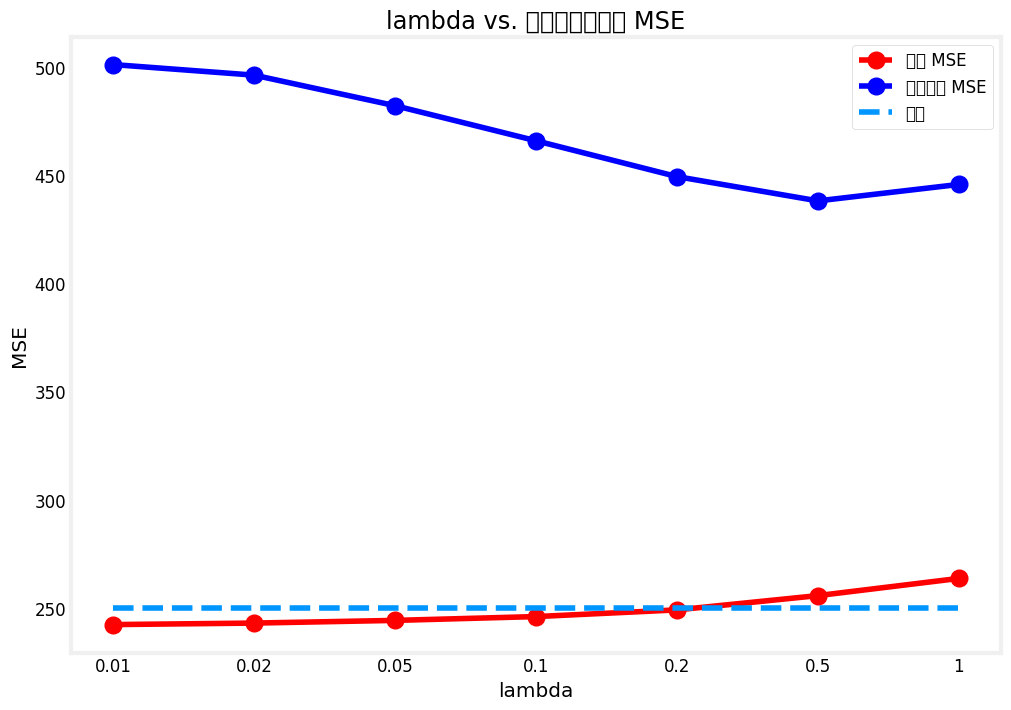

In [7]:
# 定义要绘制的lambda值
reg_params = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

# 定义多项式阶数并为每个lambda值进行训练
utils.train_plot_reg_params(reg_params, x_train, y_train, x_cv, y_cv, degree= 4, baseline=250)

### 尝试使用更小的特征集

你在上一个实验中已经看到，拥有太多的多项式项会导致过拟合。你可以减少这些项的数量，看看在哪里能得到训练误差和交叉验证误差之间的最佳平衡。减少特征数量会有所帮助的另一种情况是，当你的数据中存在不相关的特征时。例如，医院给患者分配的ID不会有助于诊断肿瘤，因此你应该确保将其从训练数据中移除。

为了说明移除特征如何改善性能，你将对2个数据集进行多项式回归：你上面使用的相同数据（2个特征）和另一个带有随机ID列的数据（3个特征）。你可以使用下面的单元格预览这些数据。注意有2列是相同的，第3列是添加的随机数。

In [8]:
# 准备包含随机ID特征的数据集
x_train, y_train, x_cv, y_cv, x_test, y_test = utils.prepare_dataset('data/c2w3_lab2_data2.csv')

# 预览前5行
print(f"first 5 rows of the training set with 2 features:\n {x_train[:5]}\n")

# 准备包含随机ID特征的数据集
x_train, y_train, x_cv, y_cv, x_test, y_test = utils.prepare_dataset('data/c2w3_lab2_data3.csv')

# 预览前5行
print(f"first 5 rows of the training set with 3 features (1st column is a random ID):\n {x_train[:5]}\n")

first 5 rows of the training set with 2 features:
 [[3.75757576e+03 5.49494949e+00]
 [2.87878788e+03 6.70707071e+00]
 [3.54545455e+03 3.71717172e+00]
 [1.57575758e+03 5.97979798e+00]
 [1.66666667e+03 1.61616162e+00]]

first 5 rows of the training set with 3 features (1st column is a random ID):
 [[1.41929130e+07 3.75757576e+03 5.49494949e+00]
 [1.51868310e+07 2.87878788e+03 6.70707071e+00]
 [1.92662630e+07 3.54545455e+03 3.71717172e+00]
 [1.25222490e+07 1.57575758e+03 5.97979798e+00]
 [1.76537960e+07 1.66666667e+03 1.61616162e+00]]



现在你将训练模型并绘制结果。图中的实线显示了具有2个特征的数据的误差，而虚线显示了具有3个特征的数据集的误差。如你所见，具有3个特征的数据集具有更高的交叉验证误差，特别是当你引入更多多项式项时。这是因为模型也在尝试从随机ID中学习，即使它与目标无关。

另一种看待它的方式是观察degree=4时的点。你会注意到，尽管具有3个特征时*训练误差*更低，但*训练误差和交叉验证误差之间的差距*比只使用2个特征时要大得多。这也应该警告你模型正在过拟合。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) m

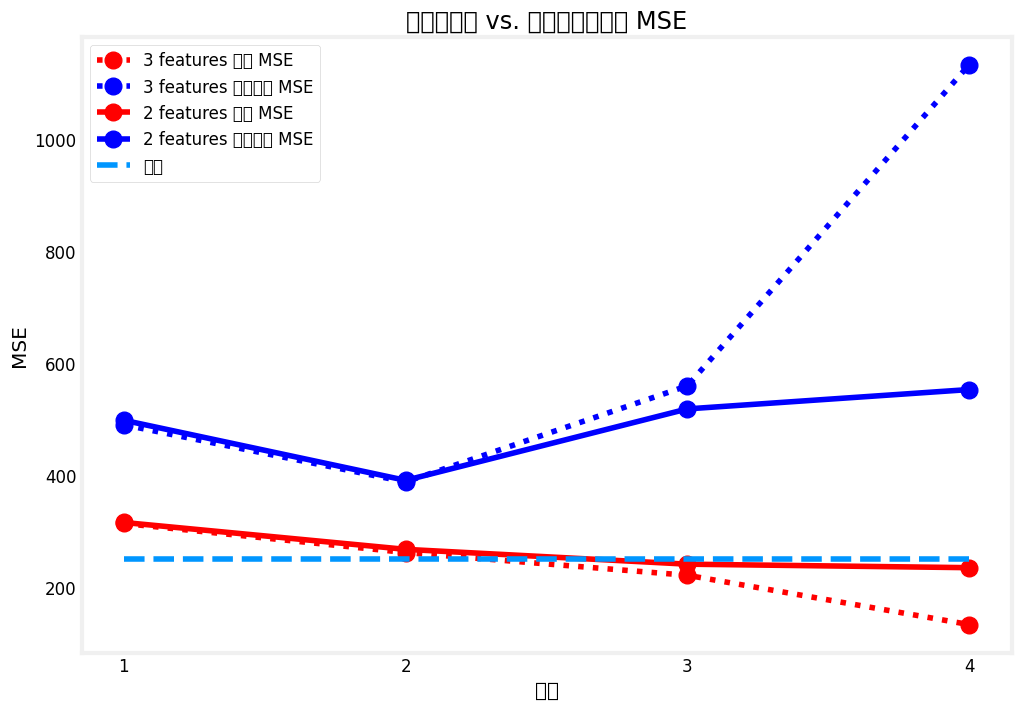

In [9]:
# 定义模型
model = LinearRegression()

# 定义两个数据集的属性
file1 = {'filename':'data/c2w3_lab2_data3.csv', 'label': '3 features', 'linestyle': 'dotted'}
file2 = {'filename':'data/c2w3_lab2_data2.csv', 'label': '2 features', 'linestyle': 'solid'}
files = [file1, file2]

# 为每个数据集训练并绘图
utils.train_plot_diff_datasets(model, files, max_degree=4, baseline=250)

### 获取更多的训练样本

最后，你可以尝试通过获取更多样本来最小化交叉验证误差。在下面的单元格中，你将训练一个4阶多项式模型，然后绘制模型的*学习曲线*，以查看当你获取更多样本时误差的变化情况。

the shape of the entire training set (input) is: (600, 2)
the shape of the entire training set (target) is: (600,)

the shape of the entire cross validation set (input) is: (200, 2)
the shape of the entire cross validation set (target) is: (200,)



/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) m

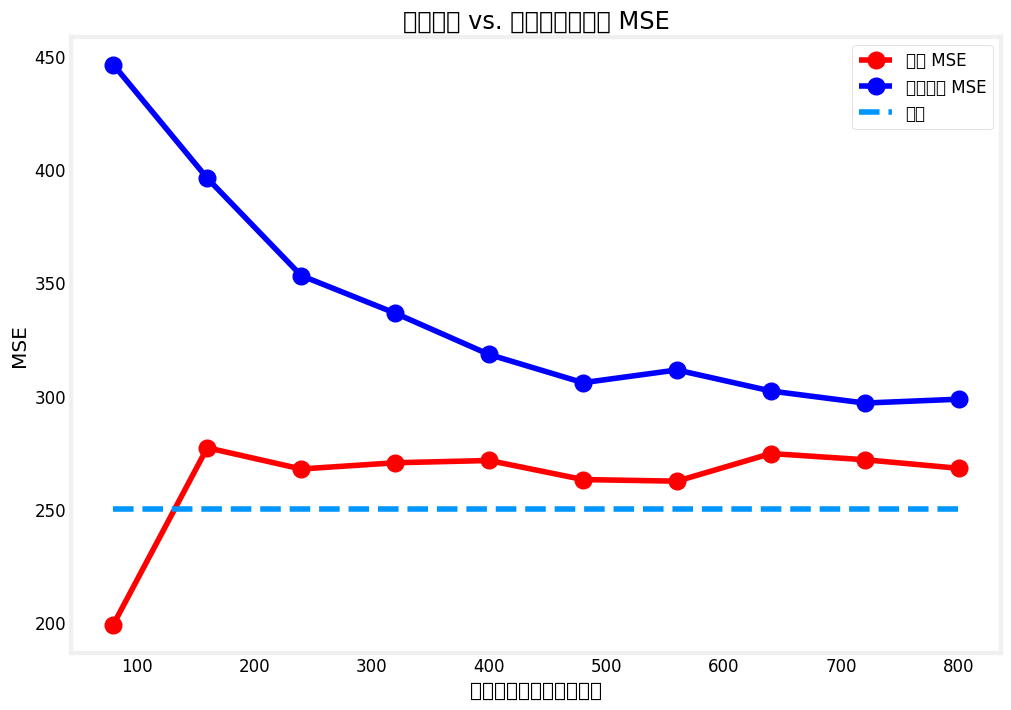

In [10]:
# 准备数据集
x_train, y_train, x_cv, y_cv, x_test, y_test = utils.prepare_dataset('data/c2w3_lab2_data4.csv')
print(f"the shape of the entire training set (input) is: {x_train.shape}")
print(f"the shape of the entire training set (target) is: {y_train.shape}\n")
print(f"the shape of the entire cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the entire cross validation set (target) is: {y_cv.shape}\n")

# 实例化模型类
model = LinearRegression()

# 定义多项式阶数并使用数据集的子集训练模型。
utils.train_plot_learning_curve(model, x_train, y_train, x_cv, y_cv, degree= 4, baseline=250)

结果显示，随着数据集大小的增加，交叉验证误差开始接近训练误差。你可以从中获得的另一个见解是，添加更多样本不太可能解决高偏差问题。这是因为即使数据集增加，训练误差也保持相对平稳。

## 总结

在本实验中，你练习了如何解决学习算法中的高偏差和高方差问题。通过学习如何发现这些问题，你已经培养了在开发机器学习模型时下一步该尝试什么的直觉。在接下来的讲座中，你将更深入地了解机器学习开发过程，并探索在项目中需要考虑的更多方面。下次见！